In [1]:
from functools import partial
import matplotlib.pyplot as plt
from superfv import HydroSolver, ics, TimeIntegrator, BC

In [2]:
N = 32
sim = HydroSolver(
    ic=partial(ics.sedov, gamma=1.4, h=1 / N),
    nx=N,
    ny=N,
    nz=N,
    bcx=(BC.REFLECTIVE, BC.FREE),
    bcy=(BC.REFLECTIVE, BC.FREE),
    bcz=(BC.REFLECTIVE, BC.FREE),
    p=1,
    use_MUSCL=True,
)

In [3]:
sim.take_n_steps(100, time_integrator=TimeIntegrator.FORWARD_EULER, print_frequency=10)

SuperFV: step 100/100 | rho_min=9.53e-03 | E_cons=3.64e-12 | wall=5.21e+00s (done)


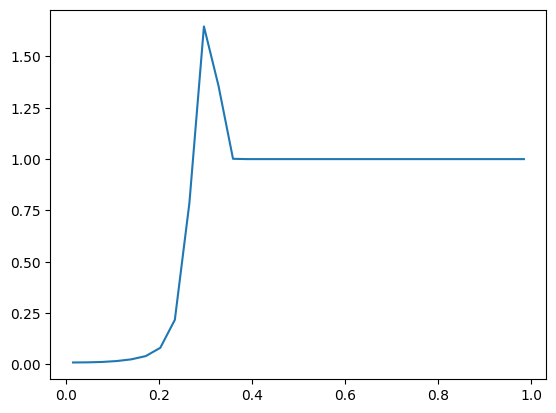

In [4]:
plt.plot(sim.mesh.x_centers, sim.snapshot_history[-1].u[sim.idx("rho"), :, 0, 0])

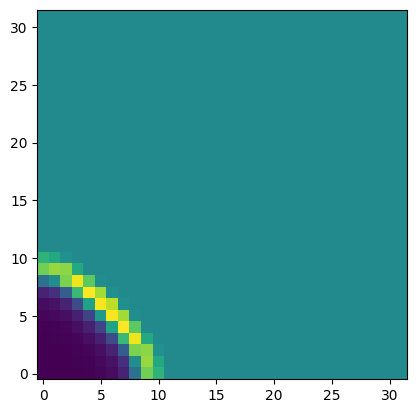

In [5]:
plt.imshow(sim.snapshot_history[-1].u[sim.idx("rho"), :, :, 0], origin="lower")